# Idea for the Image processing pipeline

### 1. Preprocessing
* Convert to grayscale with adaptive threshold

### 2. Morphological Operations
* Erosion & Dilation: Remove small noise and preserve only long, continuous structural lines

### 3. Grid Reconstruction
* Hough Lines? to detect lines

### 4. Intersection & Corner Detection
* Locate crossing points by finding pixels present in both the horizontal and vertical masks

### 5. Cell Extraction
* Detect closed contours within the grid

### 6. OCR
* Text Detection on the first row to detect each habit in each cell

### 7. Cross Detection
* On each cell detect if it is crossed or not
  * Ideas:
    * Black White pixel count
    * Diagonal lines

In [9]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BACKEND_PATH = Path("backend")
if str(BACKEND_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_PATH))

from app.table_detection import (
    load_image, resize_to_max, preprocess, detect_grid_lines, extract_line_positions, 
    draw_grid, detect_mark_in_cell
)
from app.table_detection import TableDetectionResult, CellResult

IMAGE_DIR = Path("tracker-table-images")

def show(img_bgr, title="", figsize=(14, 6), cmap=None):
    plt.figure(figsize=figsize)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if len(img_bgr.shape) == 3 else img_bgr, cmap="gray")
    else:
        plt.imshow(img_bgr, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1  Load sample images

In [10]:
all_images = sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg"))
print(f"Found {len(all_images)} images:")
for p in all_images:
    print(f"  {p.name}")

Found 4 images:
  convertet.png
  photo-edited.png
  screenshot.png
  from-web.jpg


Original size : 3888×1774
Working size  : 1800×821


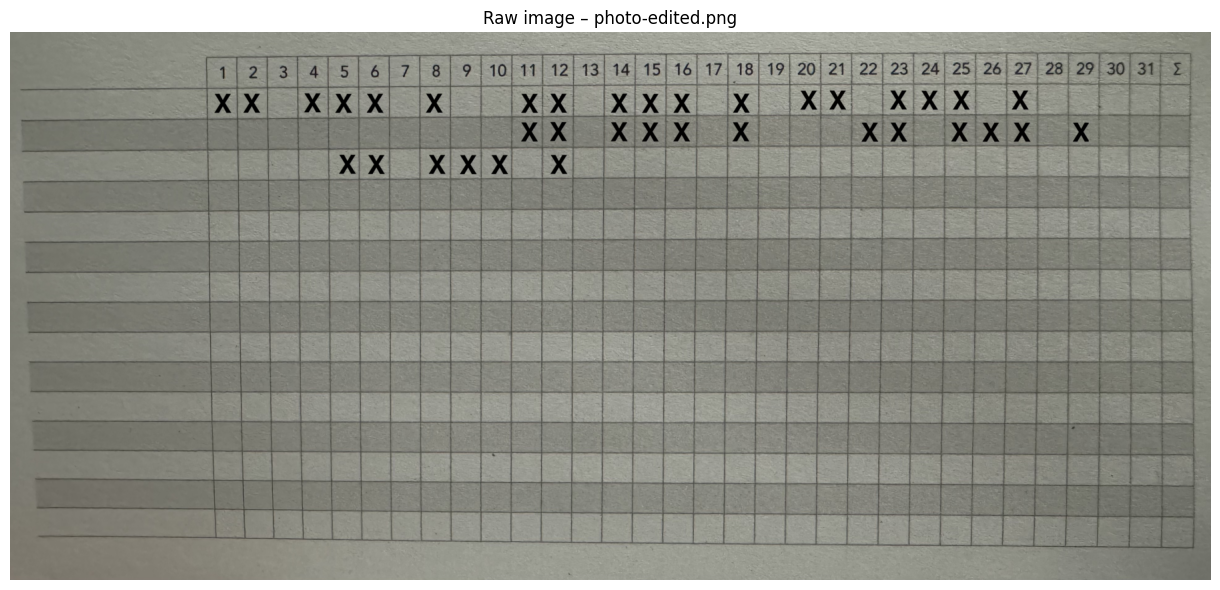

In [11]:
# Pick the image to work with in the step-by-step walk-through
SAMPLE = IMAGE_DIR / "photo-edited.png"

raw = load_image(SAMPLE)
img = resize_to_max(raw, max_dim=1800)
print(f"Original size : {raw.shape[1]}×{raw.shape[0]}")
print(f"Working size  : {img.shape[1]}×{img.shape[0]}")
show(img, f"Raw image – {SAMPLE.name}")

## 2 Preprocess

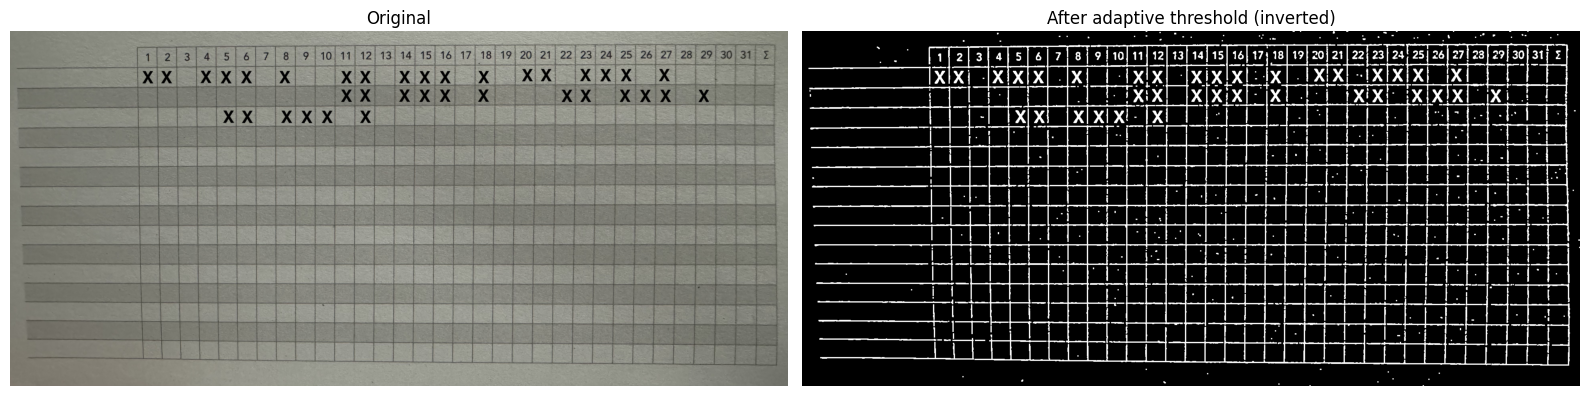

In [12]:
binary = preprocess(img)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("After adaptive threshold (inverted)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3  Grid line detection via morphology

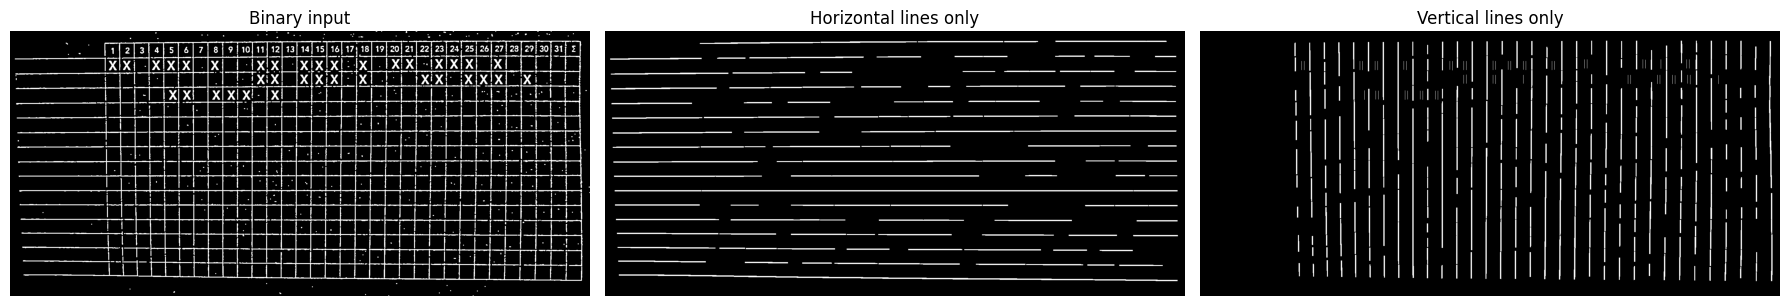

In [13]:
h_lines, v_lines = detect_grid_lines(binary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(binary, cmap="gray")
axes[0].set_title("Binary input")
axes[0].axis("off")

axes[1].imshow(h_lines, cmap="gray")
axes[1].set_title("Horizontal lines only")
axes[1].axis("off")

axes[2].imshow(v_lines, cmap="gray")
axes[2].set_title("Vertical lines only")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4  Extract lines on each axis

Horizontal lines (rows): 17  → 16 cell rows
Vertical lines (cols):   33 → 32 cell columns

Row y-positions: [33, 81, 127, 172, 218, 265, 311, 357, 403, 448, 494, 539, 585, 630, 675, 722, 768]
Col x-positions: [299, 343, 389, 434, 479, 524, 570, 615, 660, 706, 751, 797, 843, 889, 935, 981, 1027, 1073, 1119, 1166, 1212, 1258, 1307, 1351, 1398, 1447, 1493, 1540, 1586, 1632, 1679, 1725, 1771]


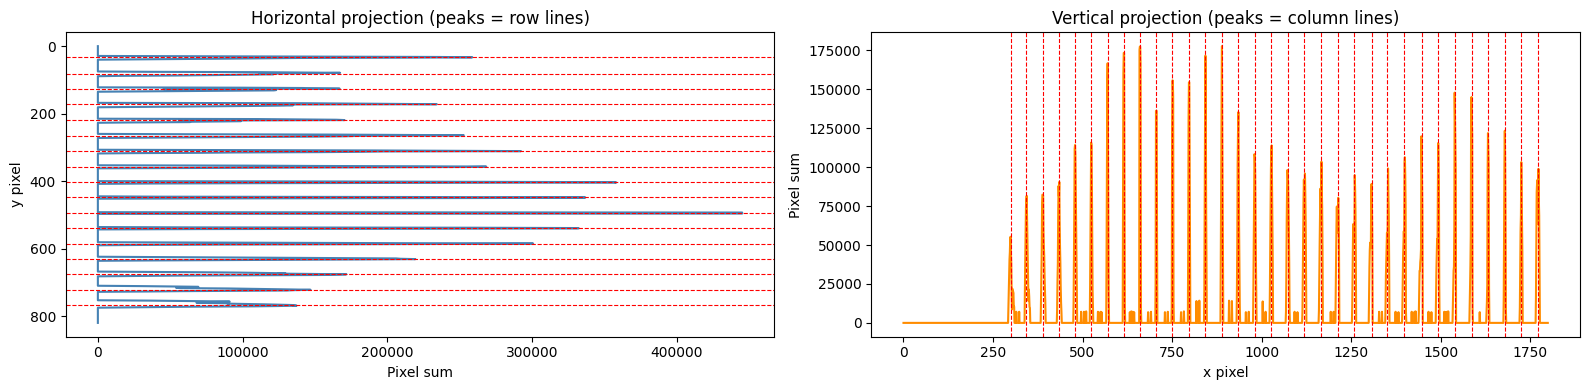

In [14]:
row_positions = extract_line_positions(h_lines, axis=1, min_gap=10)
col_positions = extract_line_positions(v_lines, axis=0, min_gap=8)

print(f"Horizontal lines (rows): {len(row_positions)}  → {len(row_positions)-1} cell rows")
print(f"Vertical lines (cols):   {len(col_positions)} → {len(col_positions)-1} cell columns")
print("\nRow y-positions:", row_positions)
print("Col x-positions:", col_positions)


h_proj = h_lines.sum(axis=1).astype(float)
v_proj = v_lines.sum(axis=0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(h_proj, range(len(h_proj)), color="steelblue")
axes[0].invert_yaxis()
for y in row_positions:
    axes[0].axhline(y=y, color="red", linewidth=0.8, linestyle="--")
axes[0].set_title("Horizontal projection (peaks = row lines)")
axes[0].set_xlabel("Pixel sum")
axes[0].set_ylabel("y pixel")

axes[1].plot(v_proj, color="darkorange")
for x in col_positions:
    axes[1].axvline(x=x, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title("Vertical projection (peaks = column lines)")
axes[1].set_xlabel("x pixel")
axes[1].set_ylabel("Pixel sum")

plt.tight_layout()
plt.show()

## 5  Visualise the detected grid

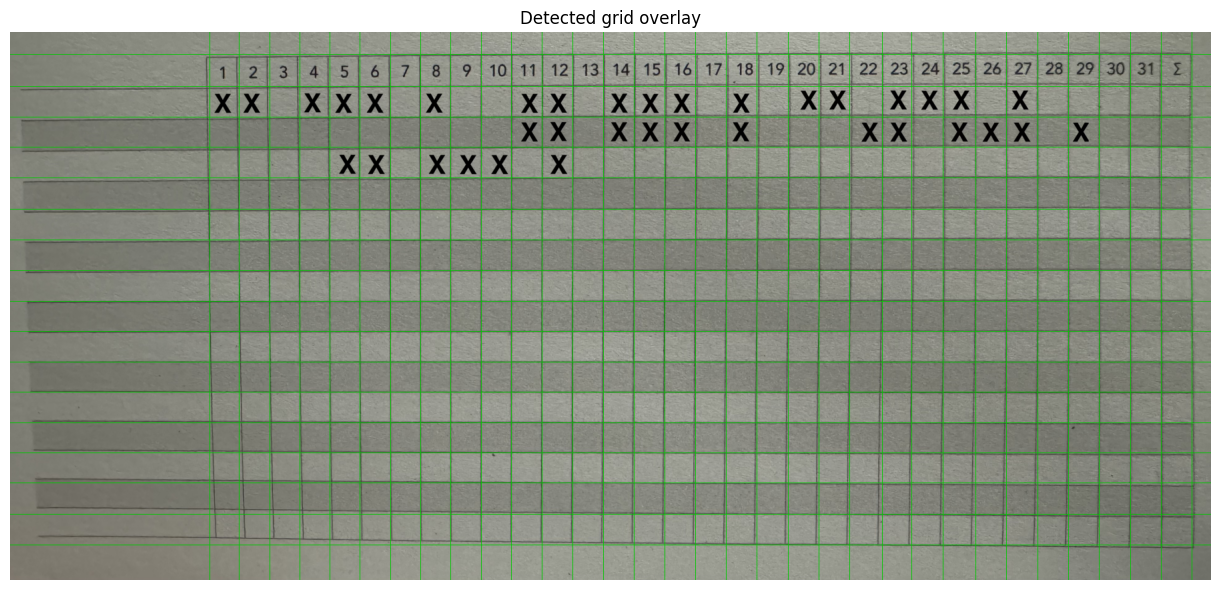

In [15]:
tableDetectionResult = TableDetectionResult(
    success=True, 
    n_rows=0, 
    n_cols=0,
    row_positions=row_positions, 
    col_positions=col_positions,
    cells=[], habit_names=[],
)
grid_img = draw_grid(img, tableDetectionResult, color=(0, 200, 0))
show(grid_img, "Detected grid overlay")

## 6 Extract individual cells

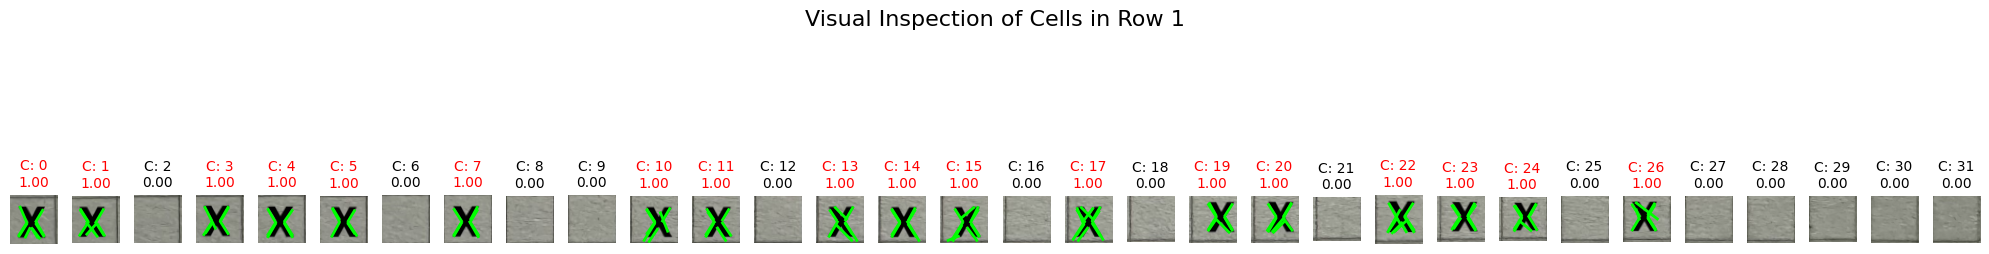

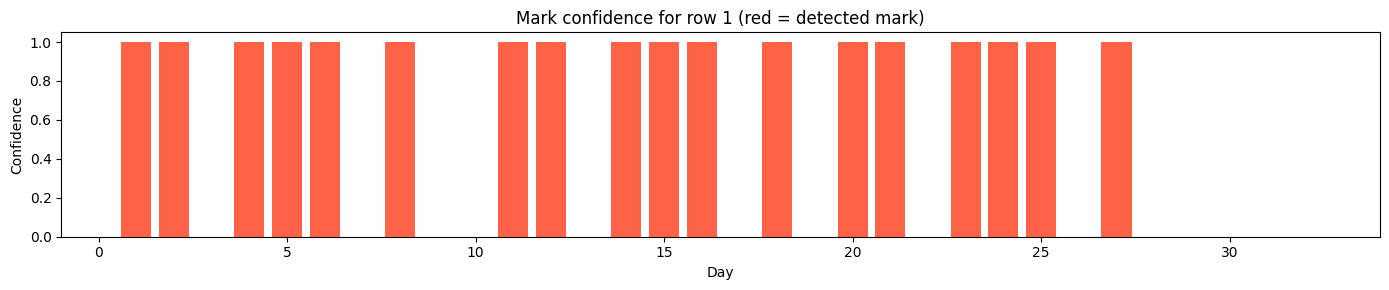

In [16]:
SAMPLE_ROW = 1
y1, y2 = row_positions[SAMPLE_ROW], row_positions[SAMPLE_ROW + 1]
n_cols = len(col_positions) - 1

fig, axes = plt.subplots(1, n_cols, figsize=(20, 4))
fig.suptitle(f"Visual Inspection of Cells in Row {SAMPLE_ROW}", fontsize=16)

densities = []
for c in range(n_cols):
    x1, x2 = col_positions[c], col_positions[c + 1]
    cell = img[y1:y2, x1:x2]
    cell_rgb = cv2.cvtColor(cell, cv2.COLOR_BGR2RGB)
        
    has_mark, conf, lines = detect_mark_in_cell(cell_rgb)
    densities.append(conf)
    
    ax = axes[c]
    ax.imshow(cell_rgb)
    
    for lx1, ly1, lx2, ly2 in lines:
        ax.plot([lx1, lx2], [ly1, ly2], color='lime', linewidth=2)
    
    title_color = "red" if has_mark else "black"
    ax.set_title(f"C: {c}\n{conf:.2f}", color=title_color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 3))
days = range(1, len(densities) + 1)
colors = ["tomato" if d > 0.2 else "steelblue" for d in densities]
plt.bar(days, densities, color=colors)
plt.xlabel("Day")
plt.ylabel("Confidence")
plt.title(f"Mark confidence for row {SAMPLE_ROW} (red = detected mark)")
plt.tight_layout()
plt.show()